# Package Import

In [1]:
import torch 

import torch.nn as nn

import torch.optim as optim

import nltk

import regex as re

import pandas as pd

import numpy as np



from matplotlib import pyplot as plt

from nltk.corpus import stopwords

from torch.utils.data import DataLoader, Dataset

from collections import Counter

import torch.nn.functional as F

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns

# Data import and cleaning

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/ai-vs-human-text-classification-dataset-2026/ai_vs_human_text_2026.csv")

df = df[["text_content", "label"]]

df["label"] = df["label"].map({"ai": 1, "human": 0})

In [3]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
def clean_data(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    words = [w for w in text.split() if w not in stop_words]

    return " ".join(words)

In [5]:
df["text_content"] = df["text_content"].apply(clean_data)

# Tokenization and Encoding functions

In [6]:
def tokenize(text):

    return text.split()



train_texts = df["text_content"]

all_tokens = [token for text in train_texts for token in tokenize(text)]

vocab = {word: i+2 for i, word in enumerate(Counter(all_tokens))} # start from 2

vocab["<PAD>"] = 0

vocab["<UNK>"] = 1

In [7]:
def encode(text, max_len=52):

        tokens = tokenize(text)

        ids = [vocab.get(t, 1) for t in tokens]

        if len(ids) < max_len:

                ids += [0] * (max_len - len(ids))

        else:

                ids = ids[:max_len]

        return ids

# Data pipeline definition

In [8]:
class TextDataset(Dataset):

        def __init__(self, texts, labels):

                self.texts = [torch.tensor(encode(t), dtype=torch.long) for t in texts]

                self.labels = torch.tensor(labels, dtype=torch.float32)



        def __len__(self):

                return len(self.texts)



        def __getitem__(self, idx):

                return self.texts[idx], self.labels[idx]

# Data Processing pipeline

In [9]:
x = df["text_content"].values
y = df["label"].to_numpy(copy=True)

In [10]:
x_train, x_val, y_train, y_val = train_test_split(x, y, random_state=42, test_size=0.3)
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, random_state=42, test_size=0.5)

train_ds = TextDataset(x_train, y_train)

val_ds = TextDataset(x_val, y_val)



train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

val_dl = DataLoader(val_ds, batch_size=32)

# Basic LSTM-based text classification

In [11]:
class AIDetector(nn.Module):

    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, out_size=2):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)

        self.fc = nn.Linear(in_features=hidden_dim, out_features=out_size)



    def forward(self, x):
    
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        x = self.fc(hidden[-1])
    
        return F.softmax(x, dim=1)

# Hyper-parameters

In [12]:
vocab_size = len(vocab)
embed_dim = 64
hidden_dim = 64
out_classes = 2
epochs = 10

# Training parameters

In [13]:
model = AIDetector(vocab_size, embed_dim, hidden_dim, out_classes)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

# Text Classification training log

Epoch 1 train loss 0.020227799415588377 acc 0.6764285714285714 val loss 0.02112611522277196 acc 0.6566666666666666
Epoch 2 train loss 0.017696920484304428 acc 0.6764285714285714 val loss 0.015384662946065266 acc 0.6566666666666666
Epoch 3 train loss 0.01305359531726156 acc 0.9092857142857143 val loss 0.01218900183836619 acc 0.95
Epoch 4 train loss 0.011482148681368147 acc 0.9507142857142857 val loss 0.01143379916747411 acc 0.97
Epoch 5 train loss 0.011134358112301145 acc 0.96 val loss 0.011300170222918193 acc 0.9733333333333334
Epoch 6 train loss 0.011023112492901938 acc 0.9628571428571429 val loss 0.011394592225551605 acc 0.97
Epoch 7 train loss 0.010995065101555415 acc 0.9635714285714285 val loss 0.011390157441298166 acc 0.97
Epoch 8 train loss 0.011014286875724793 acc 0.9635714285714285 val loss 0.011283425092697143 acc 0.9733333333333334
Epoch 9 train loss 0.010856278794152395 acc 0.9678571428571429 val loss 0.011281739175319671 acc 0.9733333333333334
Epoch 10 train loss 0.01088511

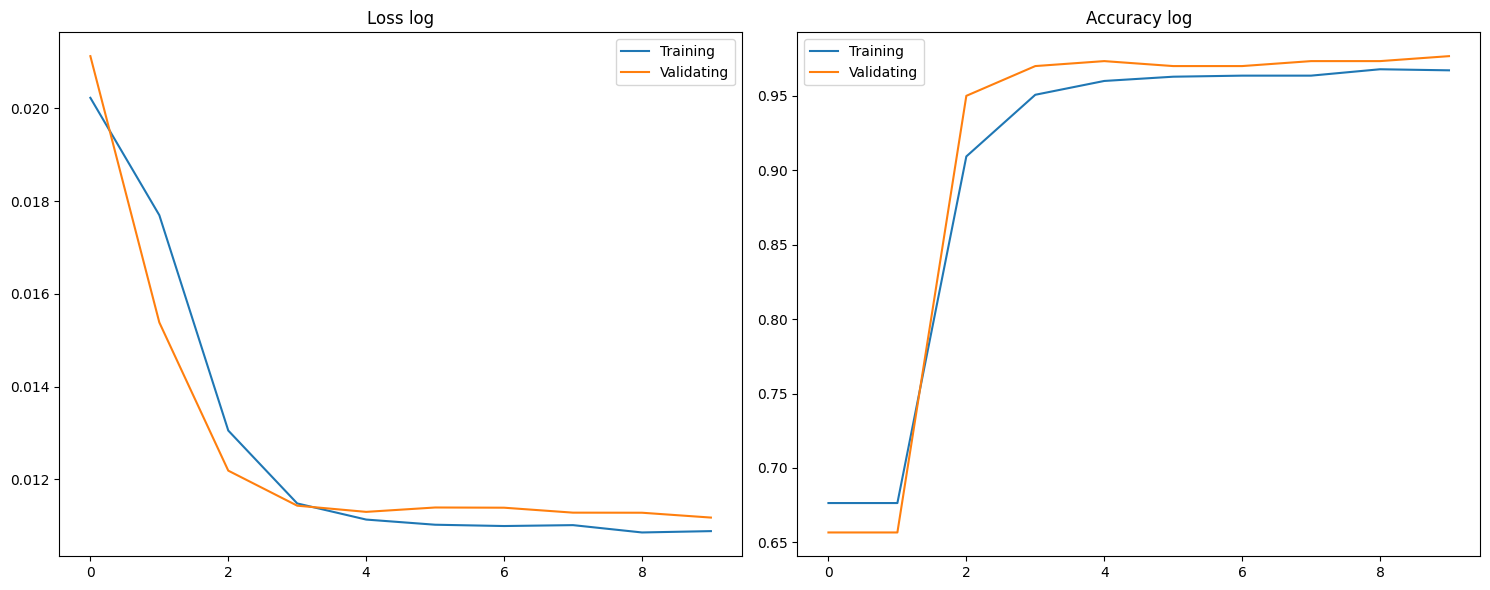

In [14]:
torch.save(model.state_dict(), "/kaggle/working/best_model.pt")

# best_model = deepcopy(model)
best_acc = 0

train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, epochs+1):
    model.train()

    diff = 0
    acc = 0
    total = 0

    for data, target in train_dl:
        optimizer.zero_grad()
        if torch.cuda.is_available():
            data, target = data.cuda(), target.cuda()

        out = model(data)
        loss = criterion(out, target.type(torch.int64))
        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

        loss.backward()
        optimizer.step()

    train_loss += [diff/total]
    train_acc += [acc/total]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        
        for data, target in val_dl:
            optimizer.zero_grad()
            if torch.cuda.is_available():
                data, target = data.cuda(), target.cuda()

            out = model(data)
            loss = criterion(out, target.type(torch.int64))
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss += [diff/total]
    val_acc += [acc/total]

    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        torch.save(model.state_dict(), "/kaggle/working/best_model.pt")

    print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

# Text Classification inference

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       188
           1       0.95      0.94      0.95       112

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



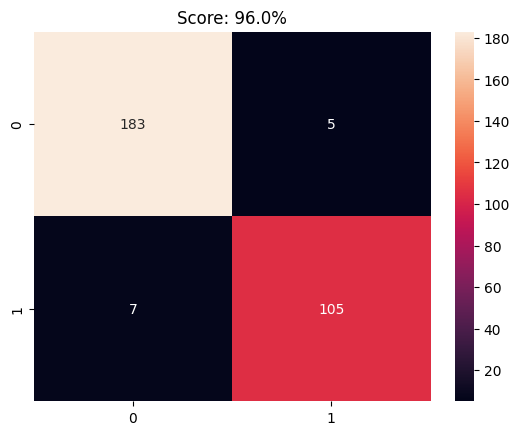

In [15]:
best_model = AIDetector(vocab_size, embed_dim, hidden_dim, out_classes)
best_model = best_model.to(device)
best_model.load_state_dict(torch.load("/kaggle/working/best_model.pt", weights_only=True))

def predict(text):

    txt = torch.tensor(encode(text), dtype=torch.long)
    txt = txt.view(1, txt.shape[0])

    best_model.eval()
    with torch.no_grad():
        if torch.cuda.is_available():
            txt = txt.cuda()
        out = best_model(txt)

    index = out.argmax(1).item()

    return index, round(out[0][index].item()*100, 2)

truth = []
preds = []
probas = []

for i in range(x_test.shape[0]):
    truth += [y_test[i]]
    pred, proba = predict(x_test[i])
    preds += [pred]
    probas += [proba]

score = accuracy_score(preds, truth)
print(classification_report(preds, truth))
sns.heatmap(confusion_matrix(preds, truth), annot=True, fmt='d')
plt.title("Score: {}%".format(round(score*100, 2)))
plt.show()